In [2]:
import torch
from ch_4.build_gpt import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-key-value bias
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [12]:
from ch_5.ch5 import create_dataloader_v1

file_path = "D://codes//llm-evaluation//more_exercise//the-verdict.txt"

with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    text_data[:split_idx],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True
)
val_loader = create_dataloader_v1(
    text_data[split_idx:],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False
)

2


In [7]:
'''
1: 学习率预热

学习率预热可以稳定复杂模型（如 LLM）的训练。这个过程包括将学习率从一个非常低的初始值 (initial_lr) 逐渐增加到用户指定的最大值 (peak_lr)。
以较小的权重更新开始训练可以降低模型在其训练阶段遇到大的、不稳定的更新的风险。
'''
n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01
warmup_steps = 20

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_increment = (peak_lr - initial_lr) / warmup_steps         #A

global_step = -1
track_lrs = []

for epoch in range(n_epochs):                                #B
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:                       #C
        	lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr

        for param_group in optimizer.param_groups:           #D
        	param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])    #E


#A 此增量决定了在 20 个预热步骤中的每一步，我们将 initial_lr 增加多少。
#B 执行一个典型的训练循环，在每个 epoch 中遍历训练 loader 中的批次。
#C 如果我们仍在预热阶段，则更新学习率。
#D 将计算出的学习率应用于优化器。
#E 在一个完整的训练循环中，损失和模型更新将在此处计算，为了简单起见，本示例中省略了这些。



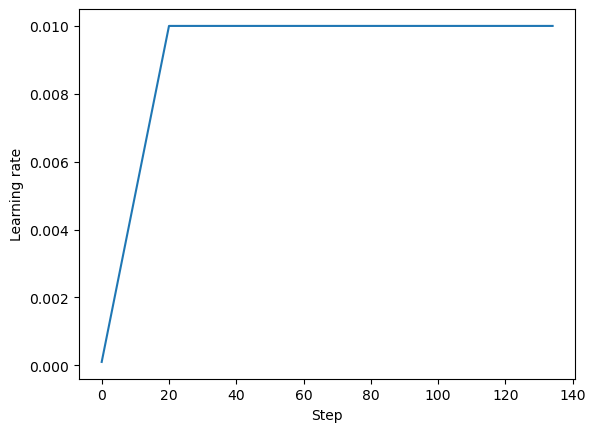

In [8]:
import matplotlib.pyplot as plt
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs)
plt.show()

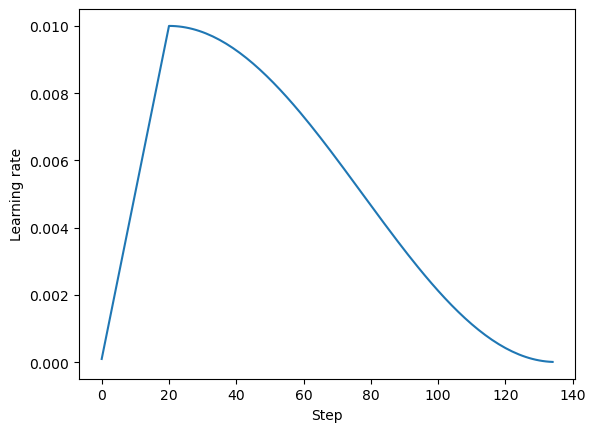

In [13]:
'''
2: 余弦衰减

在整个训练周期中调整学习率，使其在预热阶段后遵循余弦曲线。
余弦衰减将学习率降低（或衰减）至接近于零，模仿半个余弦周期的轨迹。余弦衰减中学习率的逐渐降低旨在减缓模型更新其权重的速度。
这一点非常重要，因为它有助于最大限度地降低在训练过程中越过最小损失值的风险，这对于确保训练在其后期阶段的稳定性至关重要。
'''
import math

min_lr = 0.1 * initial_lr
track_lrs = []
lr_increment = (peak_lr - initial_lr) / warmup_steps
global_step = -1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:
       		lr = initial_lr + global_step * lr_increment
        else:
            progress = ((global_step - warmup_steps) /
                        (total_training_steps - warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

        for param_group in optimizer.param_groups:
        		param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

plt.ylabel("Learning rate")
plt.xlabel("Step")
plt.plot(range(total_training_steps), track_lrs)
plt.show()

In [20]:
# 在 PyTorch 的 clip_grad_norm_ 函数中应用 max_norm=1.0 设置可以确保梯度的范数不超过 1.0
# https://github.com/skindhu/Build-A-Large-Language-Model-CN/blob/main/cn-Book/%E9%99%84%E5%BD%95D.%E7%BB%99%E8%AE%AD%E7%BB%83%E5%BE%AA%E7%8E%AF%E6%B7%BB%E5%8A%A0%E9%AB%98%E7%BA%A7%E6%8A%80%E5%B7%A7.md
'''
3: 梯度裁剪
该方法涉及设置一个阈值，当梯度超过该阈值时，会被缩小到预定的最大幅度。
这个过程确保了反向传播期间模型参数的更新保持在一个可控的范围内，增强了LLM训练期间的稳定性。
'''

from ch_5.ch5 import calc_loss_batch

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
loss = calc_loss_batch(input_batch, target_batch, model, device)
loss.backward()

In [21]:
# 在调用 .backward() 之后，通过该函数扫描模型权重张量的所有 .grad 属性来识别最高的梯度值

def find_highest_gradient(model):
    max_grad = None
    for param in model.parameters():
        if param.grad is not None:
            grad_values = param.grad.data.flatten()
            max_grad_param = grad_values.max()
            if max_grad is None or max_grad_param > max_grad:
            		max_grad = max_grad_param
    return max_grad
print(find_highest_gradient(model))

tensor(0.0423)


In [24]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(find_highest_gradient(model))

tensor(0.0192)


In [25]:
'''
4: 修改后的训练函数
'''

from ch_5.ch5 import evaluate_model, generate_and_print_sample

ORIG_BOOK_VERSION = False


def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-05, min_lr=1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1

    # Retrieve the maximum learning rate from the optimizer
    peak_lr = optimizer.param_groups[0]["lr"]

    # Calculate the total number of iterations in the training process
    total_training_steps = len(train_loader) * n_epochs

    # Calculate the learning rate increment during the warmup phase
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1

            # Adjust the learning rate based on the current phase (warmup or cosine annealing)
            if global_step < warmup_steps:
                # Linear warmup
                lr = initial_lr + global_step * lr_increment
            else:
                # Cosine annealing after warmup
                progress = ((global_step - warmup_steps) /
                            (total_training_steps - warmup_steps))
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

            # Apply the calculated learning rate to the optimizer
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
            track_lrs.append(lr)  # Store the current learning rate

            # Calculate and backpropagate the loss
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            # Apply gradient clipping after the warmup phase to avoid exploding gradients
            if ORIG_BOOK_VERSION:
                if global_step > warmup_steps:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            else:
                if global_step >= warmup_steps:  # the book originally used global_step > warmup_steps, which lead to a skipped clipping step after warmup
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            tokens_seen += input_batch.numel()

            # Periodically evaluate the model on the training and validation sets
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,
                    device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                # Print the current losses
                print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        # Generate and print a sample from the model to monitor progress
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen, track_lrs

In [27]:
import tiktoken

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

peak_lr = 0.001  # this was originally set to 5e-4 in the book by mistake
optimizer = torch.optim.AdamW(model.parameters(), lr=peak_lr, weight_decay=0.1)  # the book accidentally omitted the lr assignment
tokenizer = tiktoken.get_encoding("gpt2")

n_epochs = 15
train_losses, val_losses, tokens_seen, lrs = train_model(
    model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
    eval_freq=5, eval_iter=1, start_context="Every effort moves you",
    tokenizer=tokenizer, warmup_steps=warmup_steps,
    initial_lr=1e-5, min_lr=1e-5
)

Ep 1 (Iter 000000): Train loss 10.924, Val loss 10.939
Ep 1 (Iter 000005): Train loss 9.161, Val loss 9.302
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Iter 000010): Train loss 7.508, Val loss 7.746
Ep 2 (Iter 000015): Train loss 6.279, Val loss 6.629
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 3 (Iter 000020): Train loss 5.839, Val loss 6.838
Ep 3 (Iter 000025): Train loss 5.937, Val loss 6.862
Every effort moves you------------, and, and, and, the--, and, I had, and, and, the, and, the, and, the, the, the, I, the, and, the, I, I
Ep 4 (Iter 000030): Train loss 5.674, Val loss 6.749
Ep 4 (Iter 000035): Train loss 4.882, Val loss 6.887
Every effort moves you. I had the the the the the the the the the the the. I had the the the, and the, and the the the. I had the the the the the the the the. I had the the the the. I had the
Ep 5 (Iter 000040): Train loss 4.425, Val loss 6.579
Every effort moves you know the was, in the p

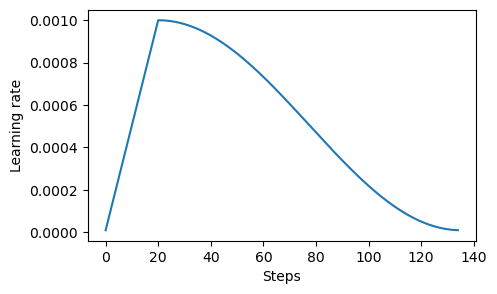

In [28]:
# 画出学习率的曲线
plt.figure(figsize=(5, 3))
plt.plot(range(len(lrs)), lrs)
plt.ylabel("Learning rate")
plt.xlabel("Steps")
plt.show()

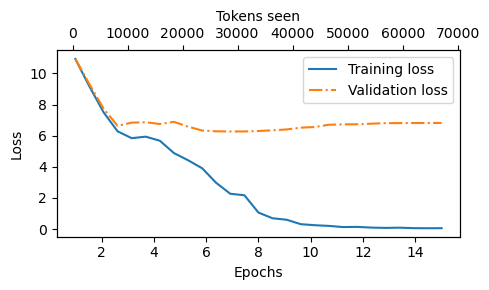

<Figure size 640x480 with 0 Axes>

In [29]:
from ch_5.ch5 import plot_losses

epochs_tensor = torch.linspace(1, n_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)
plt.tight_layout(); plt.savefig("tips_train_lr.pdf")
plt.show()